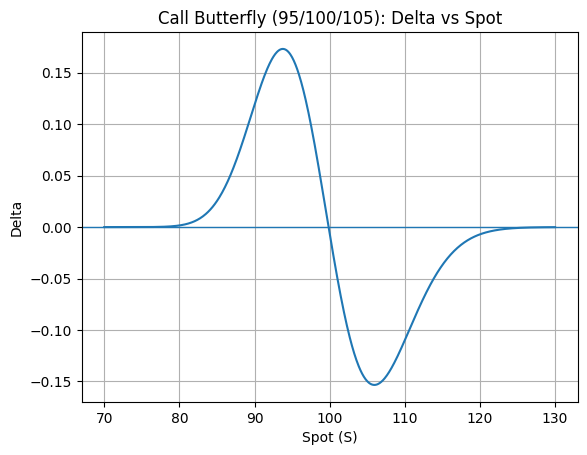

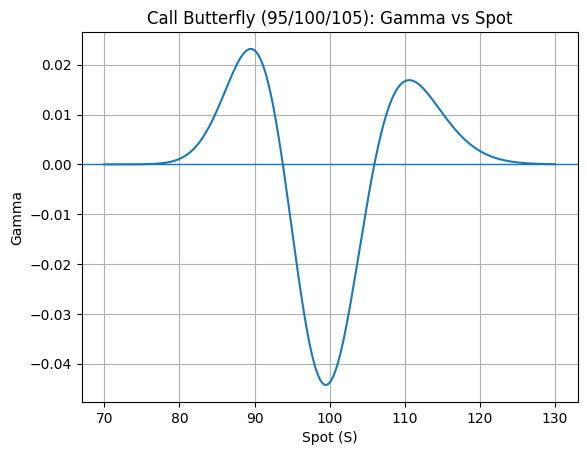

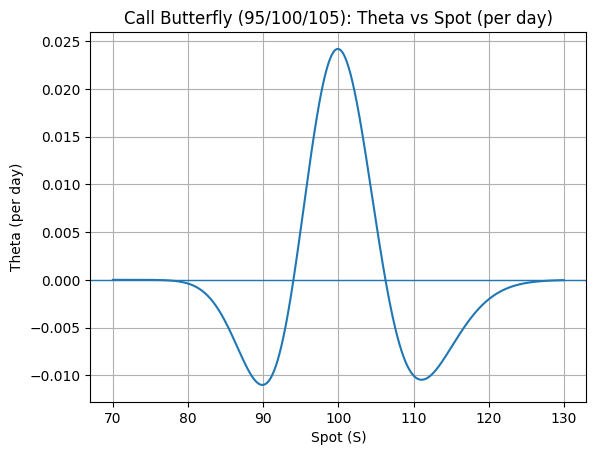

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, exp, erf, pi

# -----------------------------
# Black–Scholes helpers (no div)
# -----------------------------
def _norm_cdf(x: np.ndarray) -> np.ndarray:
    return 0.5 * (1.0 + np.vectorize(erf)(x / sqrt(2.0)))

def _norm_pdf(x: np.ndarray) -> np.ndarray:
    return (1.0 / sqrt(2.0 * pi)) * np.exp(-0.5 * x * x)

def _d1_d2(S, K, T, r, sigma):
    S = np.asarray(S, dtype=float)
    if T <= 0 or sigma <= 0:
        raise ValueError("Require T > 0 and sigma > 0.")
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def bs_call_delta(S, K, T, r, sigma):
    d1, _ = _d1_d2(S, K, T, r, sigma)
    return _norm_cdf(d1)

def bs_call_gamma(S, K, T, r, sigma):
    d1, _ = _d1_d2(S, K, T, r, sigma)
    return _norm_pdf(d1) / (S * sigma * np.sqrt(T))

def bs_call_theta(S, K, T, r, sigma):
    """
    Theta per YEAR (standard Black–Scholes, no dividends).
    """
    d1, d2 = _d1_d2(S, K, T, r, sigma)
    term1 = -(S * _norm_pdf(d1) * sigma) / (2.0 * np.sqrt(T))
    term2 = -r * K * np.exp(-r * T) * _norm_cdf(d2)
    return term1 + term2

# ---------------------------------------
# Butterfly: +1 C(K1) -2 C(K2) +1 C(K3)
# ---------------------------------------
def butterfly_greeks(S, K1, K2, K3, T, r, sigma):
    delta = (bs_call_delta(S, K1, T, r, sigma)
             - 2.0 * bs_call_delta(S, K2, T, r, sigma)
             + bs_call_delta(S, K3, T, r, sigma))

    gamma = (bs_call_gamma(S, K1, T, r, sigma)
             - 2.0 * bs_call_gamma(S, K2, T, r, sigma)
             + bs_call_gamma(S, K3, T, r, sigma))

    theta = (bs_call_theta(S, K1, T, r, sigma)
             - 2.0 * bs_call_theta(S, K2, T, r, sigma)
             + bs_call_theta(S, K3, T, r, sigma))

    return delta, gamma, theta

# -----------------------------
# Parameters (edit as desired)
# -----------------------------
K1, K2, K3 = 95.0, 100.0, 105.0
T = 30.0 / 365.0      # 30 days to expiry
r = 0.03              # 3% risk-free rate
sigma = 0.20          # 20% vol

# Underlying grid to sketch over
S = np.linspace(70, 130, 800)

delta, gamma, theta = butterfly_greeks(S, K1, K2, K3, T, r, sigma)

# Optional: express theta per DAY instead of per year
theta_per_day = theta / 365.0

# -----------------------------
# Plot
# -----------------------------
fig1, ax1 = plt.subplots()
ax1.plot(S, delta)
ax1.set_title("Call Butterfly (95/100/105): Delta vs Spot")
ax1.set_xlabel("Spot (S)")
ax1.set_ylabel("Delta")
ax1.axhline(0, linewidth=1)
ax1.grid(True)

fig2, ax2 = plt.subplots()
ax2.plot(S, gamma)
ax2.set_title("Call Butterfly (95/100/105): Gamma vs Spot")
ax2.set_xlabel("Spot (S)")
ax2.set_ylabel("Gamma")
ax2.axhline(0, linewidth=1)
ax2.grid(True)

fig3, ax3 = plt.subplots()
ax3.plot(S, theta_per_day)
ax3.set_title("Call Butterfly (95/100/105): Theta vs Spot (per day)")
ax3.set_xlabel("Spot (S)")
ax3.set_ylabel("Theta (per day)")
ax3.axhline(0, linewidth=1)
ax3.grid(True)

plt.show()
